In [8]:
import os
for dirname, _, filenames in os.walk('C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8ddaa5a5caa5caa8.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8ddaac1bd6c8cd0a.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8ddd5ec1c0de38c4.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8def3f60308ab41b.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8def4d91382175c3.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8df452e2e38c0b6e.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8dfae9d78cc32089.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8e3dbccdfe08c850.jpg
C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images\Test\Healthy\8e68163c62dc57d5.jpg
C:/Users/kosti/Desktop/DATASCI 281/w2

In [9]:
import os

dataset_dir = "C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images"
for folder in os.listdir(dataset_dir):
    print(f"Folder: {folder}")
    subfolder_path = os.path.join(dataset_dir, folder)
    if os.path.isdir(subfolder_path):
        print(f"Subfolders in {folder}: {os.listdir(subfolder_path)}")

Folder: Test
Subfolders in Test: ['Healthy', 'Powdery', 'Rust']
Folder: Train
Subfolders in Train: ['Healthy', 'Powdery', 'Rust']
Folder: Validation
Subfolders in Validation: ['Healthy', 'Powdery', 'Rust']


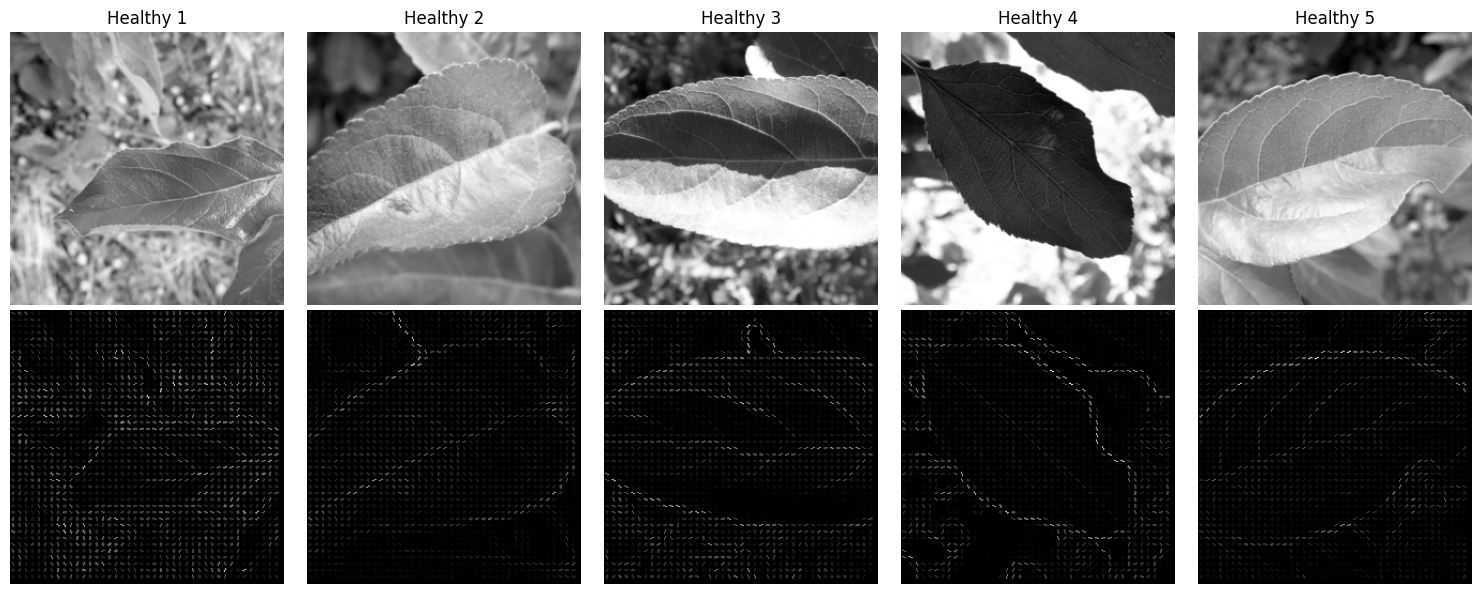

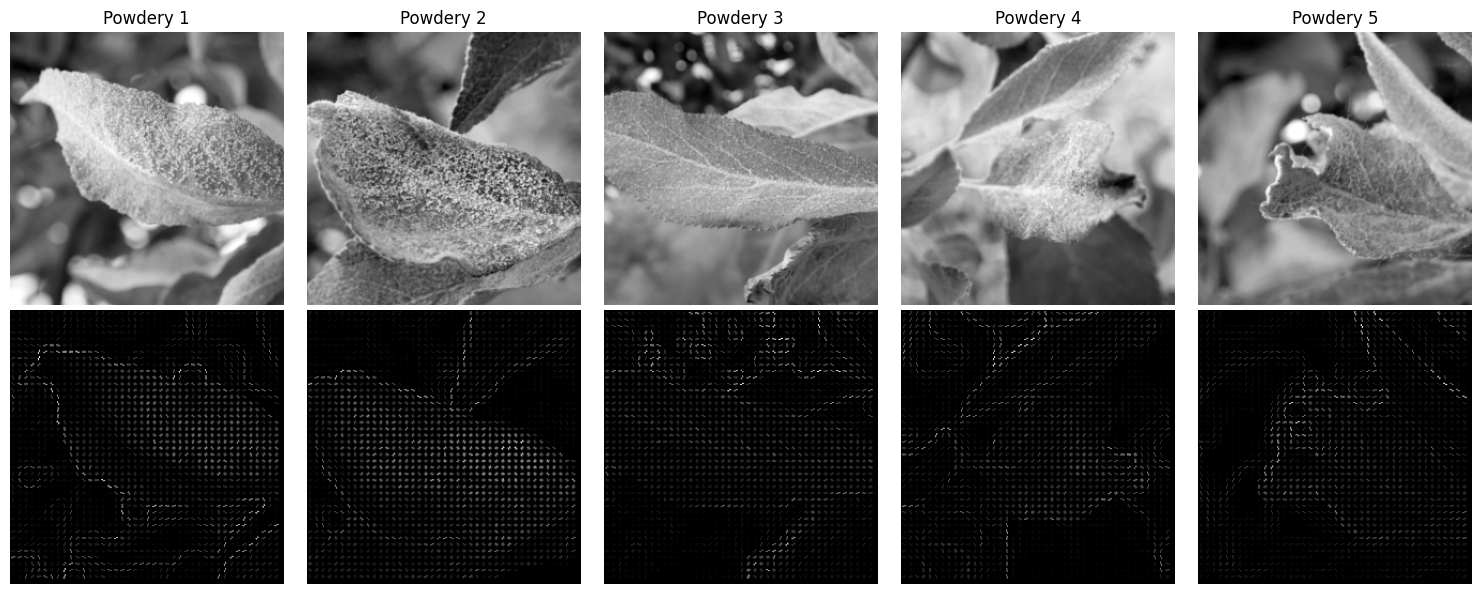

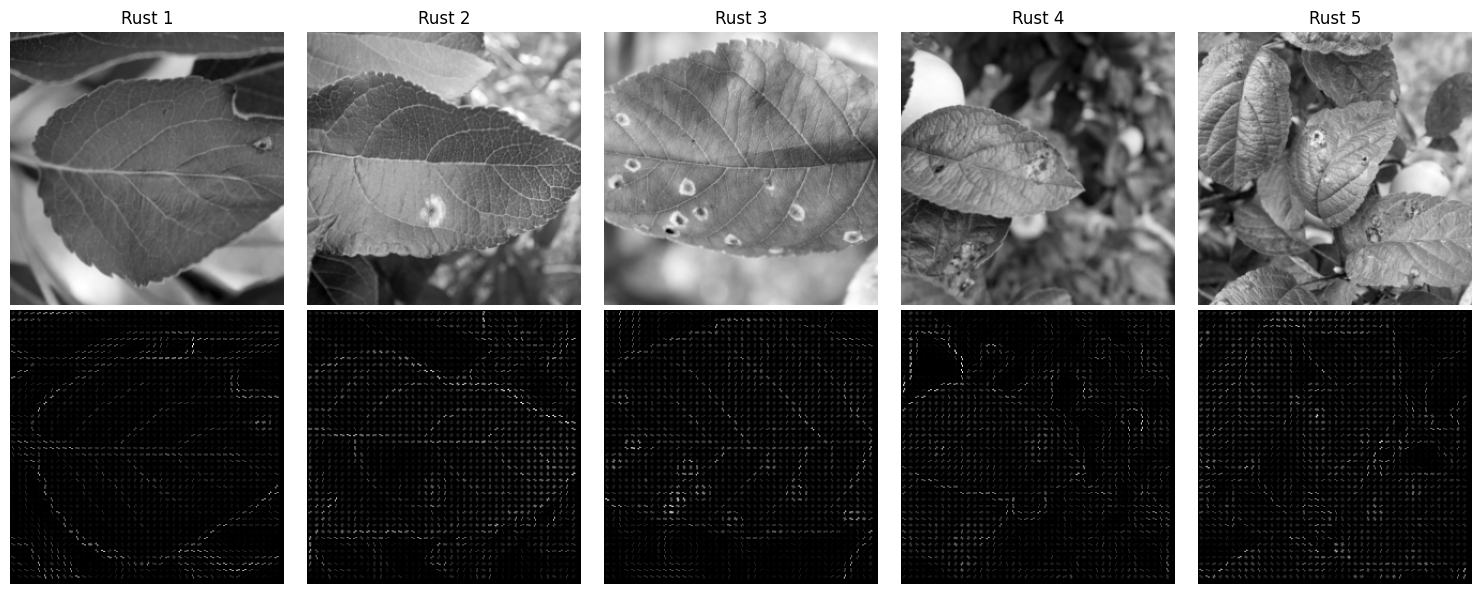

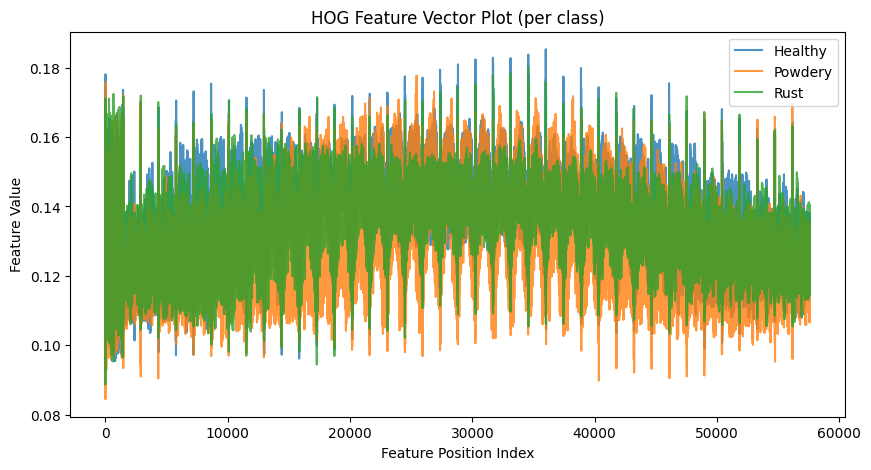

Processed 1322 images across 3 classes.
Processed 60 images across 3 classes.
Train  data: 1322 samples, 3 classes
Validation data: 60 samples, 3 classes


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.transform import rescale
from skimage.color import rgb2gray
from PIL import Image

# read image, convert to grayscale, scale
def read_image(in_path):
    img = np.array(Image.open(in_path))
    if np.max(img) > 1:
        img = img.astype(np.float32) / 255.0
    if len(img.shape) > 2:
        img = rgb2gray(img)
    return img

# rescale short side to standard, crop center
def rescale_image(img, standard=256):
    x, y = img.shape
    scale_factor = standard / min(x, y)
    img_rescaled = rescale(img, scale_factor)
    x_new, y_new = img_rescaled.shape
    start_h = (x_new - standard) // 2
    start_w = (y_new - standard) // 2
    cropped_img = img_rescaled[start_h:start_h + standard, start_w:start_w + standard]
    return cropped_img

# load images from folder and extract HOG features
def load_hog_data(folder_path, visualize=False, max_visualize=5):
    features, labels = [], []
    class_features = {}

    for label in os.listdir(folder_path):
        
        class_dir = os.path.join(folder_path, label)
        if not os.path.isdir(class_dir):
            continue
        class_features[label] = []

        visualize_count = 0
        imgs_to_show, hots_to_show = [], []

        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            img = read_image(image_path)
            img_resized = rescale_image(img)

            # visualize only first max_visualize images per class
            vis = visualize and visualize_count < max_visualize

            if vis:
                f, h = hog(
                    img_resized,
                    orientations=4,
                    pixels_per_cell=(6,6),
                    visualize=True
                )
                imgs_to_show.append(img_resized)
                hots_to_show.append(h)
                visualize_count += 1
            else:
                f = hog(
                    img_resized,
                    orientations=4,
                    pixels_per_cell=(6,6),
                    visualize=False
                )

            features.append(f)
            labels.append(label)
            class_features[label].append(f)

        # plot images and HOGs
        if visualize_count > 0:
            n = len(imgs_to_show)
            fig, axs = plt.subplots(2, n, figsize=(3*n,6))
            for i in range(n):
                axs[0,i].imshow(imgs_to_show[i], cmap='gray')
                axs[0,i].axis('off')
                axs[0,i].set_title(f'{label} {i+1}')
                axs[1,i].imshow(hots_to_show[i], cmap='gray')
                axs[1,i].axis('off')
            plt.tight_layout()
            plt.show()

    # plot HOG feature vectors
    if visualize:
        plt.figure(figsize=(10, 5))
        for label, feats in class_features.items():
            feats_array = np.array(feats)
            mean_feat = feats_array.mean(axis=0)
            plt.plot(mean_feat, alpha=0.8, label=label)

        plt.title("HOG Feature Vector Plot (per class)")
        plt.xlabel("Feature Position Index")
        plt.ylabel("Feature Value")
        plt.legend()
        plt.show()

    print(f"Processed {len(features)} images across {len(set(labels))} classes.")
    return np.array(features), np.array(labels)


train_dir = "C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images/Train"
valid_dir = "C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images/Validation"
test_dir = "C:/Users/kosti/Desktop/DATASCI 281/w281-plant-disease-recognition/images/Test"

train_features, train_labels = load_hog_data(train_dir, visualize=True, max_visualize=5)
valid_features, valid_labels = load_hog_data(valid_dir)
test_features, test_labels = load_hog_data(test_dir)

print(f"Train  data: {train_features.shape[0]} samples, {len(set(train_labels))} classes")
print(f"Validation data: {valid_features.shape[0]} samples, {len(set(valid_labels))} classes")
print(f"Test data: {test_features.shape[0]} samples, {len(set(test_labels))} classes")


In [11]:
# from sklearn.svm import SVC
# from sklearn.metrics import classification_report, accuracy_score

# # define and train the model
# svm = SVC(kernel='linear', random_state=123)
# svm.fit(train_features, train_labels)

# # validate the model
# pred_valid = svm.predict(valid_features)
# print(classification_report(valid_labels, pred_valid))
# print(f"Accuracy on validation set: {accuracy_score(valid_labels, pred_valid):.2f}")

In [ ]:
from sklearn.preprocessing import StandardScaler

# scale features (may improve performance)
# disable if it doesn't
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
valid_features_scaled = scaler.transform(valid_features)
test_features_scaled = scaler.transform(test_features)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# define and train the model
logreg = LogisticRegression(max_iter=1000, C=0.001, random_state=123, solver='lbfgs', class_weight='balanced')
logreg.fit(train_features_scaled, train_labels)

# validate the model
valid_pred = logreg.predict(valid_features_scaled)
print(classification_report(valid_labels, valid_pred))
print(f"Accuracy on validation set: {accuracy_score(valid_labels, valid_pred):.2f}")

              precision    recall  f1-score   support

     Healthy       0.65      0.75      0.70        20
     Powdery       0.71      0.60      0.65        20
        Rust       0.50      0.50      0.50        20

    accuracy                           0.62        60
   macro avg       0.62      0.62      0.62        60
weighted avg       0.62      0.62      0.62        60

Accuracy on validation set: 0.62


In [42]:
# test the model
test_pred = logreg.predict(test_features_scaled)
print(classification_report(test_labels, test_pred))
print(f"Accuracy on test set: {accuracy_score(test_labels, test_pred):.2f}")

              precision    recall  f1-score   support

     Healthy       0.46      0.54      0.50        50
     Powdery       0.62      0.50      0.56        50
        Rust       0.45      0.46      0.46        50

    accuracy                           0.50       150
   macro avg       0.51      0.50      0.50       150
weighted avg       0.51      0.50      0.50       150

Accuracy on test set: 0.50
